In [4]:
import pandas as pd

df = pd.read_csv("cleaned_nassau_candy_distributor.csv")

In [5]:
product_summary = df.groupby("Product Name").agg({
    "Sales": "sum",
    "Gross Profit":"sum",
    "Units":"sum"
}).reset_index()

product_summary["Gross Margin %"] = (
    product_summary["Gross Profit"] /
    product_summary["Sales"]
) * 100

product_summary["Profit Per Unit"] = (
    product_summary["Gross Profit"] /
    product_summary["Units"]
)

product_summary.sort_values(
    by="Gross Profit",
    ascending=False
)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit Per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00
14,Wonka Gum,597.50,310.70,478,52.000000,0.65
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
4,Kazookles,1205.75,92.75,371,7.692308,0.25
3,Hair Toffee,76.50,59.50,17,77.777778,3.50


In [6]:
top_sales = product_summary.sort_values(
    by="Sales",
    ascending=False 
)

top_sales.head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit Per Unit
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00
4,Kazookles,1205.75,92.75,371,7.692308,0.25
14,Wonka Gum,597.50,310.70,478,52.000000,0.65
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25


In [7]:
top_margin = product_summary.sort_values(
    by="Gross Margin %",
    ascending=False
)

top_margin.head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit Per Unit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
3,Hair Toffee,76.50,59.50,17,77.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
14,Wonka Gum,597.50,310.70,478,52.000000,0.65


Sales Chart

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

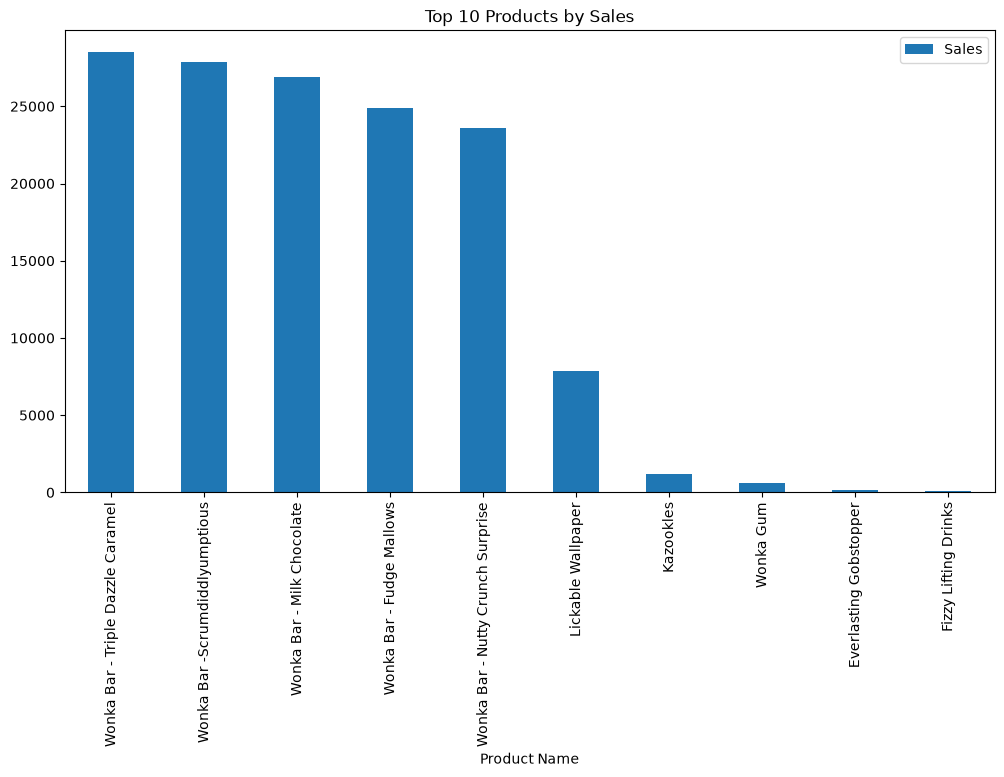

In [10]:
top_sales.head(10).plot(
    x="Product Name",
    y="Sales",
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Products by Sales")
plt.show()

Profit Chart

In [12]:
top_profit = product_summary.sort_values(
    by="Gross Profit",
    ascending=False
)

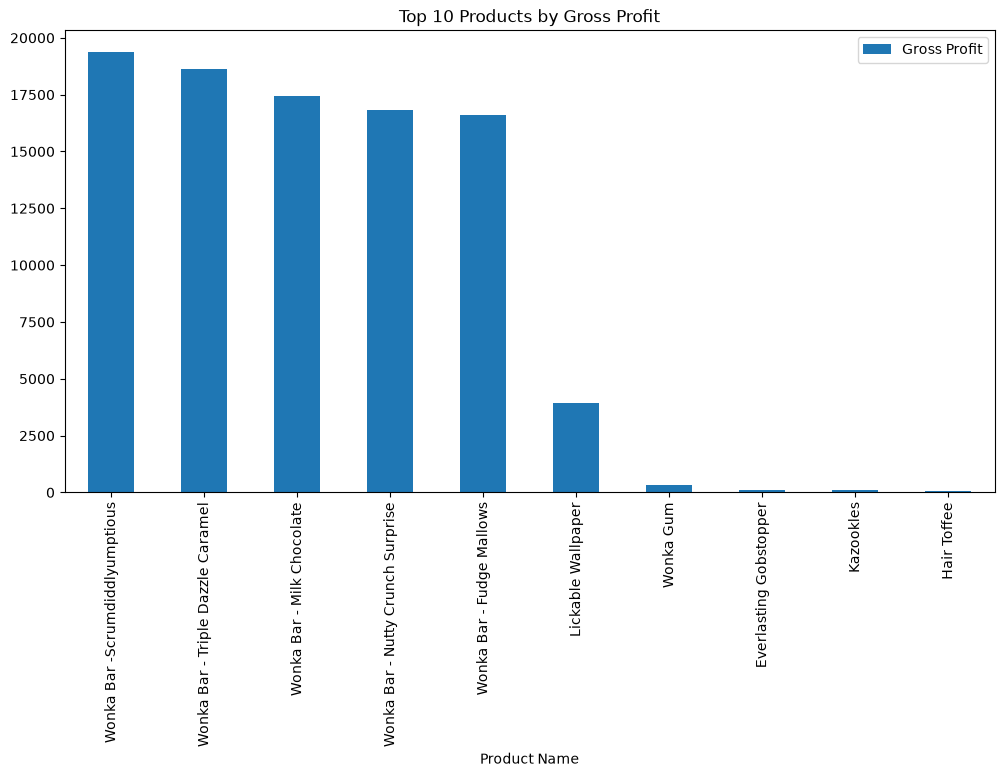

In [13]:
top_profit.head(10).plot(
    x="Product Name",
    y="Gross Profit",
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Products by Gross Profit")
plt.show()

Margin Chart

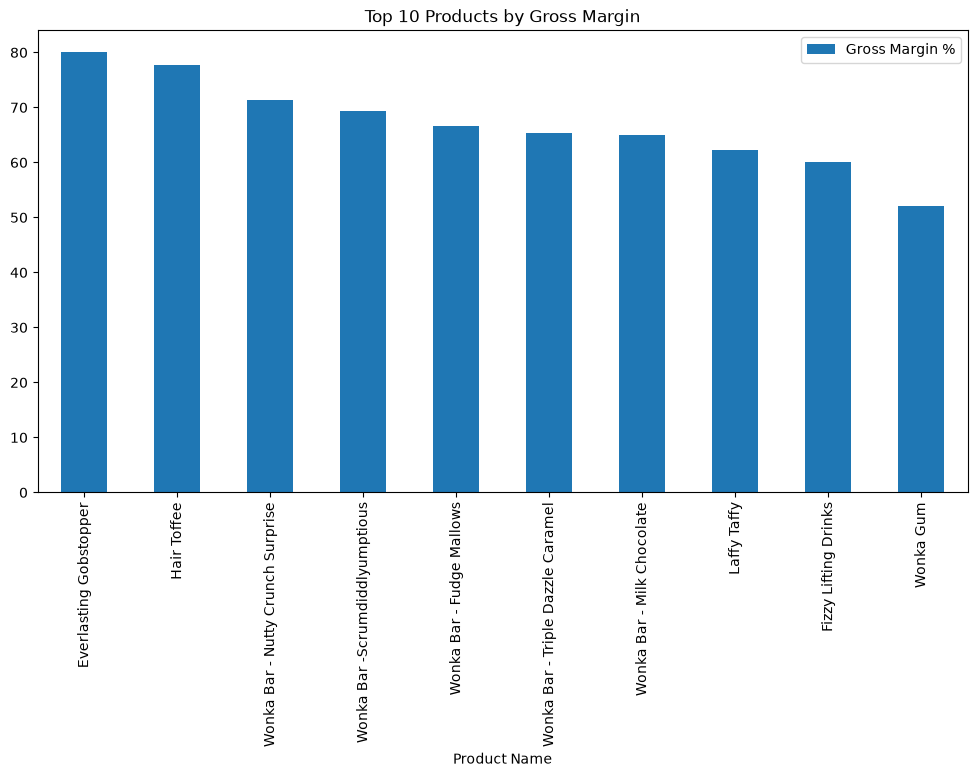

In [14]:
top_margin.head(10).plot(
    x="Product Name",
    y="Gross Margin %",
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Products by Gross Margin")
plt.show()

In [15]:
avg_sales = product_summary["Sales"].mean()

avg_profit = product_summary["Gross Profit"].mean()

In [16]:
def classify(row):

    if row["Sales"] >= avg_sales and row["Gross Profit"] >= avg_profit:
        return "Star Product"

    elif row["Sales"] >= avg_sales and row["Gross Profit"] < avg_profit:
            return "High Sales Low Profit"

    elif row["Sales"] < avg_sales and row["Gross Profit"] >= avg_profit:
            return "Hidden Opportunity"

    else:
          return "Weak Product"

product_summary["Category"] = product_summary.apply(
      classify,
      axis=1
)

product_summary

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit Per Unit,Category
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,Weak Product
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25,Weak Product
2,Fun Dip,12.00,4.80,8,40.000000,0.60,Weak Product
3,Hair Toffee,76.50,59.50,17,77.777778,3.50,Weak Product
4,Kazookles,1205.75,92.75,371,7.692308,0.25,Weak Product
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24,Weak Product
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,Weak Product
7,Nerds,15.00,7.00,10,46.666667,0.70,Weak Product
8,SweeTARTS,61.50,28.70,41,46.666667,0.70,Weak Product
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,Star Product


In [17]:
top5_sales = top_sales.head(5)["Sales"].sum()

total_sales = product_summary["Sales"].sum()

(top5_sales / total_sales) * 100

np.float64(92.88300772099008)

In [18]:
top5_profit = top_profit.head(5)["Gross Profit"].sum()

total_profit = product_summary["Gross Profit"].sum()

(top5_profit / total_profit) * 100

np.float64(95.05774655725214)

In [19]:
top_margin.head(10)

,Product Name,Sales,Gross Profit,Units,Gross Margin %,Profit Per Unit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
3,Hair Toffee,76.50,59.50,17,77.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
14,Wonka Gum,597.50,310.70,478,52.000000,0.65


Margin Anlysis:

Highest Margin Product:
Everlasting Gobstopper

Sales - 130

Profit - 104

Margin - 80%

Second Highest Margin Product: Hair Toffee

Sales - 76.5

Profit - 59.5

Margin - 77.778%

Best Large-Scale Product : Wonka Bar - Nutty Crunch Surprise

Sales - 23,574.95

Profit - 16,819.95

Margin - 71.35%